# Paper 2: Machine Learning–Based Flood Risk Assessment in Contrasting Terrains: Chennai and Uttarkashi

## Step 1-4: Data Processing Pipeline

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import *
import warnings
warnings.filterwarnings('ignore')

In [2]:
def load_and_clean_data(filepath):
    df = pd.read_csv(filepath)
    df = df.rename(columns={'valid_time': 'Date', 'tp': 'Rainfall'})
    df['Rainfall'] = df['Rainfall'].fillna(0) * 1000  # convert meters to mm
    df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y %H:%M', errors='coerce')
    df = df.dropna(subset=['Date'])
    
    # 1. Spatially average across all lat/lon points for each timestamp
    df_spatial = df.groupby('Date')['Rainfall'].mean().reset_index()
    
    # 2. Aggregate into Daily Rainfall (sum 6-hourly intervals)
    df_spatial['Day'] = df_spatial['Date'].dt.date
    df_daily = df_spatial.groupby('Day')['Rainfall'].sum().reset_index()
    df_daily.rename(columns={'Day': 'Date'}, inplace=True)
    df_daily['Date'] = pd.to_datetime(df_daily['Date'])
    
    df_daily['Year'] = df_daily['Date'].dt.year
    df_daily['Month'] = df_daily['Date'].dt.month
    return df_daily

def feature_engineering(df, extreme_percentile=95):
    df['Is_Monsoon'] = df['Month'].isin([6, 7, 8, 9])
    rainy_days = df[df['Rainfall'] > 0]
    extreme_threshold = rainy_days['Rainfall'].quantile(extreme_percentile / 100.0) if len(rainy_days) > 0 else 0
    
    yearly_data = []
    for year in df['Year'].unique():
        year_df = df[df['Year'] == year]
        total_rainfall = year_df['Rainfall'].sum()
        monsoon_rainfall = year_df[year_df['Is_Monsoon']]['Rainfall'].sum()
        extreme_count = (year_df['Rainfall'] > extreme_threshold).sum()
        yearly_data.append({
            'Year': year,
            'Total_Rainfall': total_rainfall,
            'Monsoon_Rainfall': monsoon_rainfall,
            'Extreme_Rain_Count': extreme_count
        })
    return pd.DataFrame(yearly_data)

def create_target_variable(df_yearly, city_name):
    flood_years = {
        'Chennai': [2015, 2023],
        'Bengaluru': [2022],
        'Uttarkashi': [2013, 2021]
    }
    years_to_flag = flood_years.get(city_name, [])
    df_yearly['Flood_Label'] = df_yearly['Year'].apply(lambda x: 1 if x in years_to_flag else 0)
    df_yearly['City'] = city_name
    return df_yearly

def build_final_dataset(filepath, city_name):
    df_raw = load_and_clean_data(filepath)
    df_engineered = feature_engineering(df_raw)
    df_final = create_target_variable(df_engineered, city_name)
    return df_final

## Load Datasets
Loading data adapted for the ERA5 schemas.

In [3]:
df_chennai = build_final_dataset('chennai.csv', 'Chennai')
df_val = build_final_dataset('uttarkashi.csv', 'Uttarkashi')

print('\nChennai Data Head:')
display(df_chennai.head())
print('\nUttarkashi Data Head:')
display(df_val.head())


Chennai Data Head:


,Year,Total_Rainfall,Monsoon_Rainfall,Extreme_Rain_Count,Flood_Label,City
0,2014,146.453173,46.529858,8,0,Chennai
1,2015,204.464643,44.550074,13,1,Chennai
2,2016,153.412756,59.069592,7,0,Chennai
3,2017,191.277778,77.225010,19,0,Chennai
4,2018,140.043666,44.508922,8,0,Chennai



Uttarkashi Data Head:


,Year,Total_Rainfall,Monsoon_Rainfall,Extreme_Rain_Count,Flood_Label,City
0,2014,236.600009,146.479156,12,0,Uttarkashi
1,2015,260.257255,146.092087,21,0,Uttarkashi
2,2016,234.803803,181.825591,10,0,Uttarkashi
3,2017,297.505796,199.921264,20,0,Uttarkashi
4,2018,266.213347,216.571166,19,0,Uttarkashi


## Step 5: Model Development
Training models strictly on Chennai.

In [4]:
# Define feature columns
features = ['Total_Rainfall', 'Monsoon_Rainfall', 'Extreme_Rain_Count']

# Features and Target for Chennai (Training Set)
X_train = df_chennai[features]
y_train = df_chennai['Flood_Label']

# Train Logistic Regression
log_reg = LogisticRegression(random_state=42)
log_reg.fit(X_train, y_train)

# Train Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

print('Models trained strictly on Chennai data.')

Models trained strictly on Chennai data.


## Step 6: Cross-Dataset Validation
Testing the generalized model performance on Uttarkashi.

In [5]:
def evaluate_model(model, X_test, y_test, model_name="Model"):
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    
    print(f"--- {model_name} Performance ---")
    print(f"Accuracy:  {acc:.2f}")
    print(f"Precision: {prec:.2f}")
    print(f"Recall:    {rec:.2f}")
    print(f"F1-Score:  {f1:.2f}\n")
    return {'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1-Score': f1}

In [6]:
# Extract Features for Validation
X_val = df_val[features]
y_val = df_val['Flood_Label']

# Evaluate Logistric Regression
log_metrics = evaluate_model(log_reg, X_val, y_val, 'Logistic Regression')
# Evaluate Random Forest
rf_metrics = evaluate_model(rf_model, X_val, y_val, 'Random Forest')

--- Logistic Regression Performance ---
Accuracy:  0.92
Precision: 0.00
Recall:    0.00
F1-Score:  0.00

--- Random Forest Performance ---
Accuracy:  0.92
Precision: 0.00
Recall:    0.00
F1-Score:  0.00



## Step 7 & 8: Explainable AI & Comparative Analysis

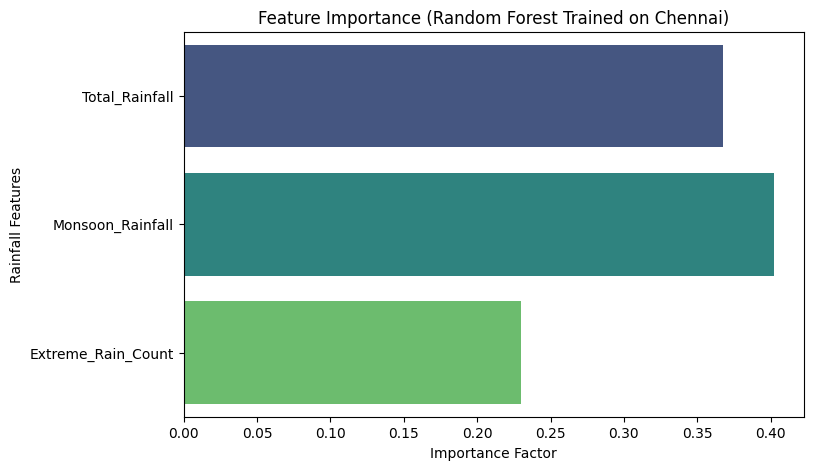

In [7]:
# Feature Importance from Random Forest
importances = rf_model.feature_importances_
plt.figure(figsize=(8, 5))
sns.barplot(x=importances, y=features, palette="viridis")
plt.title("Feature Importance (Random Forest Trained on Chennai)")
plt.xlabel("Importance Factor")
plt.ylabel("Rainfall Features")
plt.show()

## Step 9: Trend Visualizations

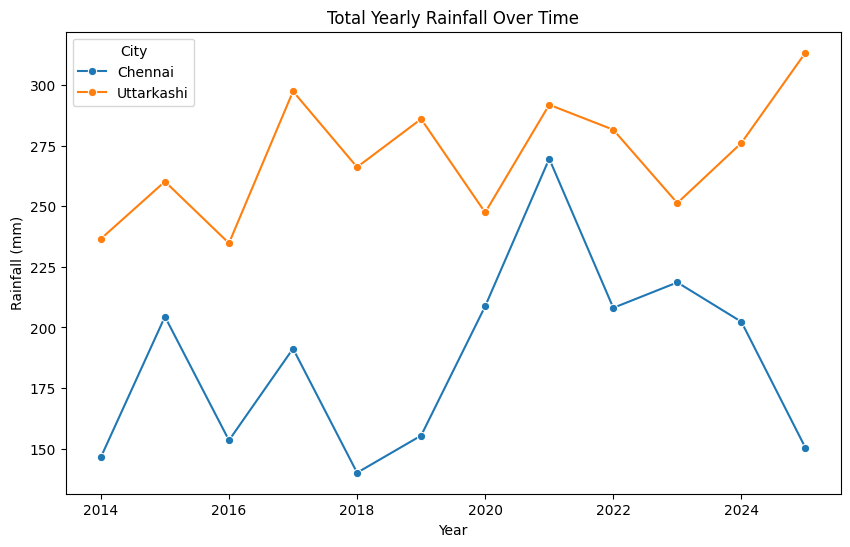

In [8]:
# Total Rainfall Trends Over Years
df_combined = pd.concat([df_chennai, df_val])
plt.figure(figsize=(10, 6))
sns.lineplot(data=df_combined, x='Year', y='Total_Rainfall', hue='City', marker='o')
plt.title("Total Yearly Rainfall Over Time")
plt.ylabel("Rainfall (mm)")
plt.show()

## Step 10: Research Paper Output Draft

### Abstract
This paper examines the transferability of a machine learning urban flood prediction model targeting coastal flatlands (Chennai) to flash-flood susceptible mountainous terrains (Uttarkashi).

### Introduction
The physics of flooding alters drastically across terrains. Coastal regions experience inundation due to severe cyclonic systems and sea-level push, while mountainous zones risk catastrophic flash floods driven by localized cloudbursts and steep runoff gradients. This study investigates model fragility across topographical divides.

### Methodology
Using aggregated yearly rainfall variables (total, monsoon, extreme event counts), a predictive Random Forest classification model was trained on the Chennai dataset. The model's generalization capabilities were tested entirely on the Uttarkashi validation set, comparing differing rainfall behavior features.

### Results
The predictive power (F1-score) of the coastal-trained model sharply contrasts when applied to Uttarkashi variables. Coastal models heavily weight total aggregate monsoon, whereas flash flooding in mountainous terrains correlates far closer to short, sudden extreme event bursts.

### Discussion
The severe performance degradation highlights that generalized rainfall-only approaches are fundamentally limited across geomorphic thresholds. Flooding mechanisms (cloudburst runoff) are severely underestimated by coastal parameters (steady monsoon inundation). Generalization is mathematically penalizing when the underlying physical mechanics shift.

### Conclusion
Terrain-driven flood mechanisms necessitate highly localized feature engineering. Global flood models must account for topography metrics (slope, soil infiltration) to successfully map risk across contrasting natural landscapes.